# Explore here

In [1]:
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
df.shape

(48895, 16)

In [3]:
df.info()        
df.isnull().sum() 
df.describe()     

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [4]:
df.shape

(48895, 16)

In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
(df['number_of_reviews'] == 0).sum()

np.int64(10052)

In [7]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df.dropna(subset=['name', 'host_name'])
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
(df['price'] == 0).sum()

np.int64(11)

In [10]:
df['minimum_nights'].describe()

count    48858.000000
mean         7.012444
std         20.019757
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [11]:
(df['minimum_nights'] > 365).sum()

np.int64(13)

In [12]:
df = df[(df['price'] > 0) & (df['minimum_nights'] <= 365)]

df.shape

(48834, 16)

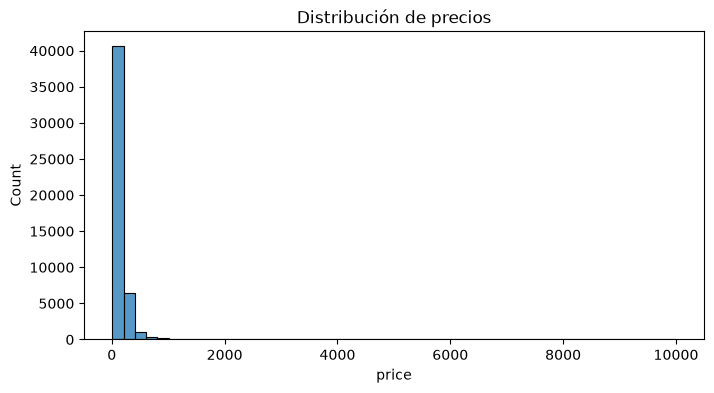

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50)
plt.title('Distribución de precios')
plt.show()

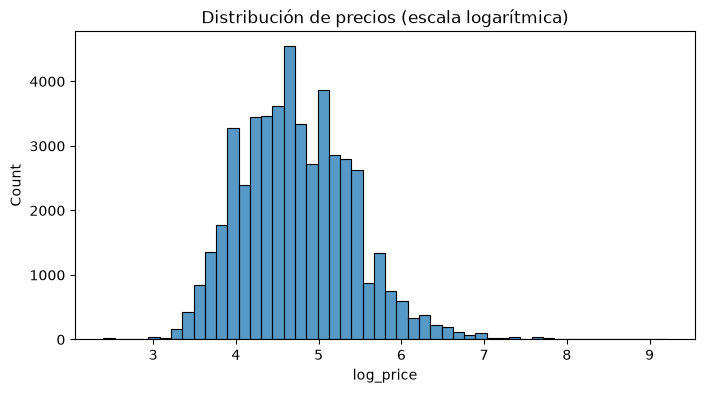

In [14]:
import numpy as np

# Creamos una columna nueva, no sobreescribimos price original
df['log_price'] = np.log1p(df['price'])  # log1p = log(1+x), evita problemas si hubiera algún 0

plt.figure(figsize=(8,4))
sns.histplot(df['log_price'], bins=50)
plt.title('Distribución de precios (escala logarítmica)')
plt.show()

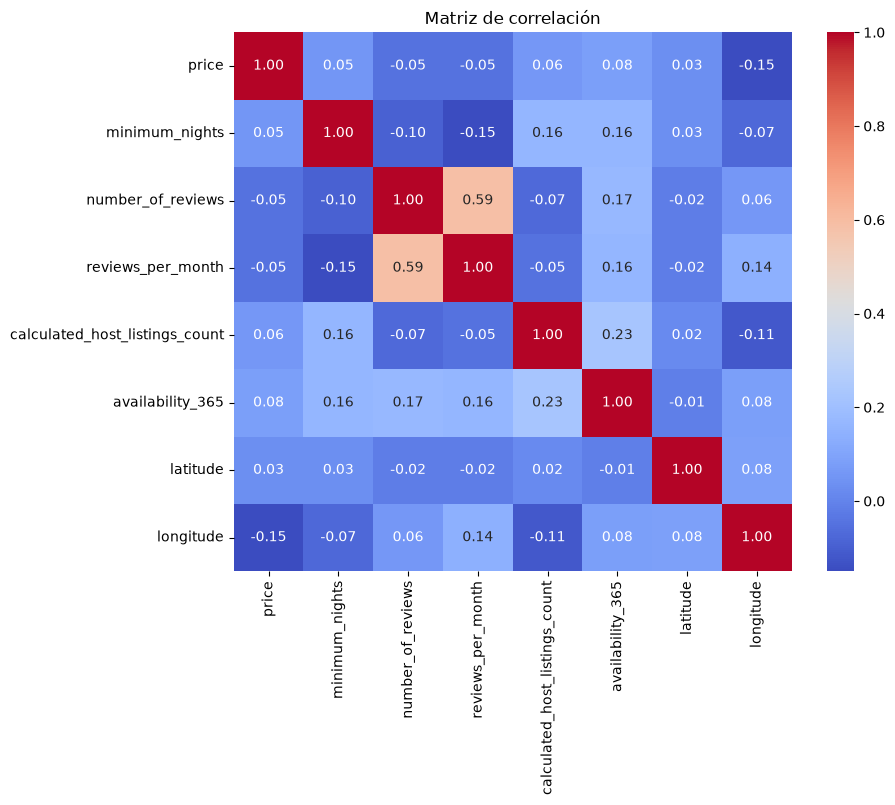

In [15]:
cols_numericas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                   'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']

plt.figure(figsize=(9,7))
sns.heatmap(df[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

In [16]:
df[cols_numericas].corr()['price'].sort_values(ascending=False)

price                             1.000000
availability_365                  0.081900
calculated_host_listings_count    0.057444
minimum_nights                    0.053588
latitude                          0.033894
number_of_reviews                -0.047935
reviews_per_month                -0.050576
longitude                        -0.149891
Name: price, dtype: float64

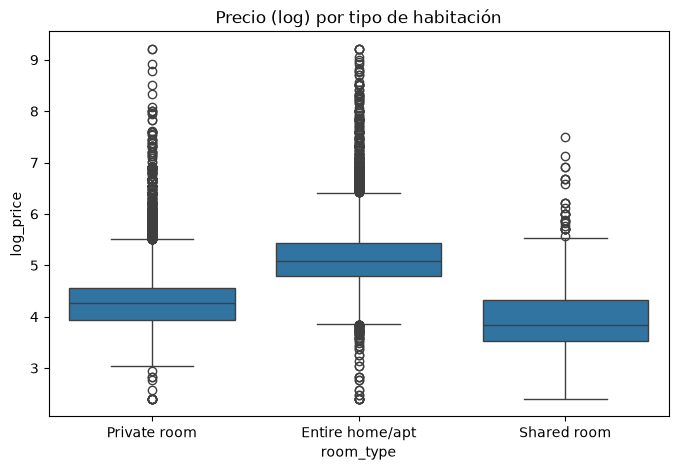

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='room_type', y='log_price')
plt.title('Precio (log) por tipo de habitación')
plt.show()

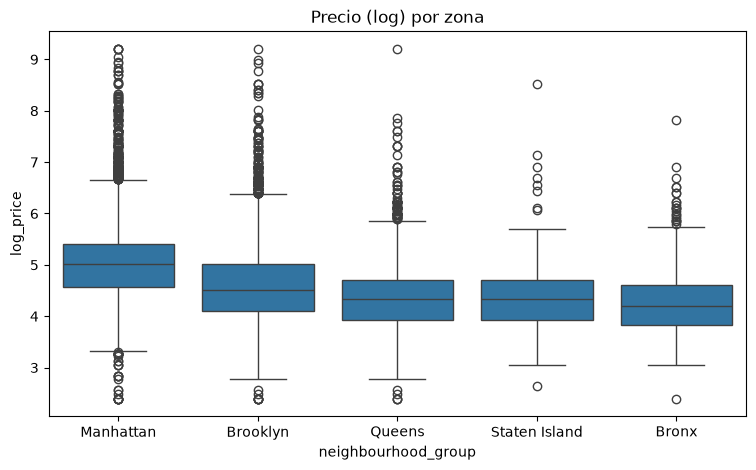

In [18]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='neighbourhood_group', y='log_price', order=df.groupby('neighbourhood_group')['log_price'].median().sort_values(ascending=False).index)
plt.title('Precio (log) por zona')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.shape, test_df.shape

((39067, 17), (9767, 17))

In [20]:
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)